In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../data/Sudan.csv')
df['Country'] = 'Sudan'
print(df.shape)
df.head()

(4108, 13)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan


In [4]:
df = df.replace(-999, np.nan)
print("Missing values after replacement:")
print(df.isna().sum())

Missing values after replacement:
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
dtype: int64


In [5]:

df['Date'] = pd.to_datetime(df['YEAR'].astype(str) + df['DOY'].astype(str).str.zfill(3), format='%Y%j')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Year,Month
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,2015,1
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,2015,1
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,2015,1
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,2015,1
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,2015,1


In [6]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Shape after dropping duplicates: {df.shape}")

Number of duplicate rows: 0
Shape after dropping duplicates: (4108, 16)


In [7]:

df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Year,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,2020.131451,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,2015.000000,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,2017.000000,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,2020.000000,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,2023.000000,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,2026.000000,12.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.248907,3.477046


In [8]:

missing_pct = df.isna().sum() / len(df) * 100
print(missing_pct[missing_pct > 0])

Series([], dtype: float64)


In [9]:
cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
outlier_counts = {}
for col in cols:
    z = np.abs(stats.zscore(df[col].dropna()))
    outliers = (z > 3).sum()
    outlier_counts[col] = outliers
    print(f"{col}: {outliers} outliers")


for col in cols:
    mean = df[col].mean()
    std = df[col].std()
    df[col] = df[col].clip(mean - 3*std, mean + 3*std)

T2M: 3 outliers
T2M_MAX: 6 outliers
T2M_MIN: 1 outliers
PRECTOTCORR: 71 outliers
RH2M: 3 outliers
WS2M: 4 outliers
WS2M_MAX: 3 outliers


In [10]:
df[cols] = df[cols].ffill()

df = df.dropna(thresh=int(0.7 * len(df.columns)))
print(f"Final shape: {df.shape}")

Final shape: (4108, 16)


In [11]:
df.to_csv('../data/sudan_clean.csv', index=False)
print("Saved cleaned data to ../data/sudan_clean.csv")

Saved cleaned data to ../data/sudan_clean.csv


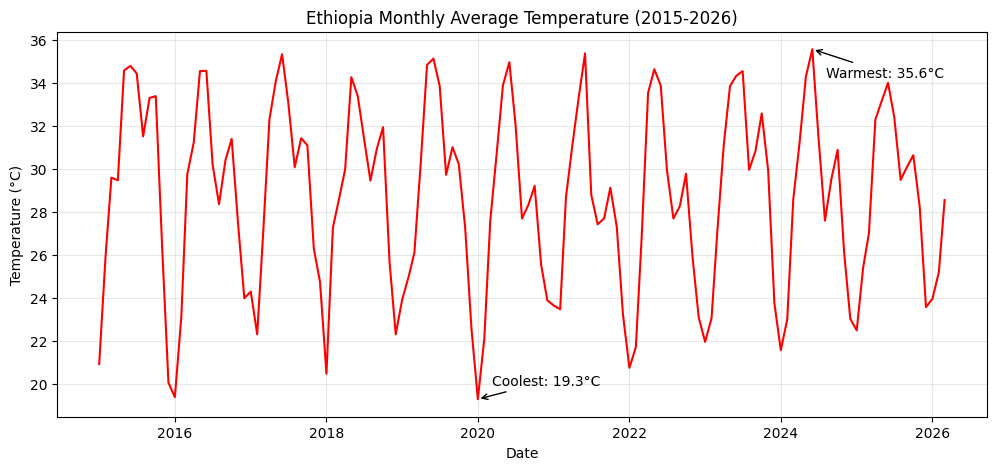

In [12]:
monthly_temp = df.groupby(['Year', 'Month'])['T2M'].mean().reset_index()
monthly_temp['Date'] = pd.to_datetime(monthly_temp['Year'].astype(str) + '-' + monthly_temp['Month'].astype(str))

plt.figure(figsize=(12,5))
plt.plot(monthly_temp['Date'], monthly_temp['T2M'], linewidth=1.5, color='red')

# Find warmest and coolest months
max_row = monthly_temp.loc[monthly_temp['T2M'].idxmax()]
min_row = monthly_temp.loc[monthly_temp['T2M'].idxmin()]
plt.annotate(f"Warmest: {max_row['T2M']:.1f}°C", xy=(max_row['Date'], max_row['T2M']),
             xytext=(10, -20), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
plt.annotate(f"Coolest: {min_row['T2M']:.1f}°C", xy=(min_row['Date'], min_row['T2M']),
             xytext=(10, 10), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
plt.title('Ethiopia Monthly Average Temperature (2015-2026)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(alpha=0.3)
plt.show()

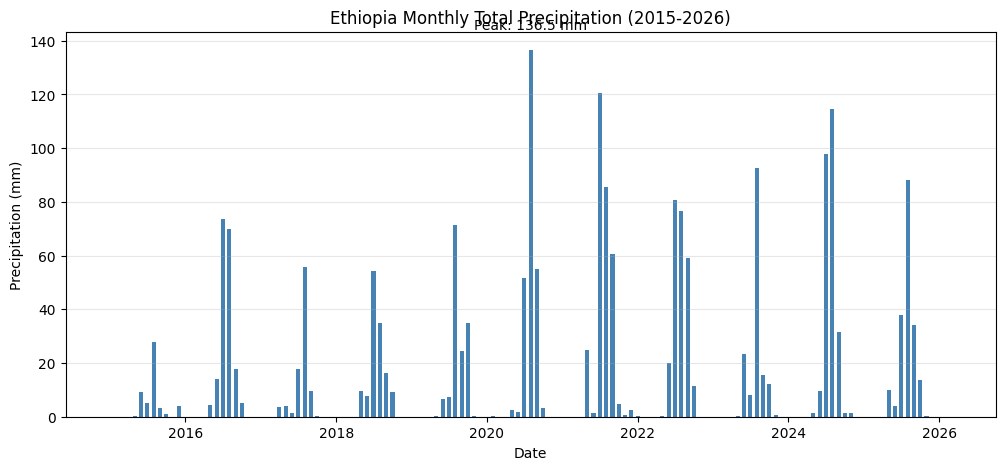

In [13]:
monthly_precip = df.groupby(['Year', 'Month'])['PRECTOTCORR'].sum().reset_index()
monthly_precip['Date'] = pd.to_datetime(monthly_precip['Year'].astype(str) + '-' + monthly_precip['Month'].astype(str))

plt.figure(figsize=(12,5))
plt.bar(monthly_precip['Date'], monthly_precip['PRECTOTCORR'], width=20, color='steelblue')
peak = monthly_precip.loc[monthly_precip['PRECTOTCORR'].idxmax()]
plt.annotate(f"Peak: {peak['PRECTOTCORR']:.1f} mm", xy=(peak['Date'], peak['PRECTOTCORR']),
             xytext=(0, 15), textcoords='offset points', ha='center')
plt.title('Ethiopia Monthly Total Precipitation (2015-2026)')
plt.xlabel('Date')
plt.ylabel('Precipitation (mm)')
plt.grid(alpha=0.3, axis='y')
plt.show()

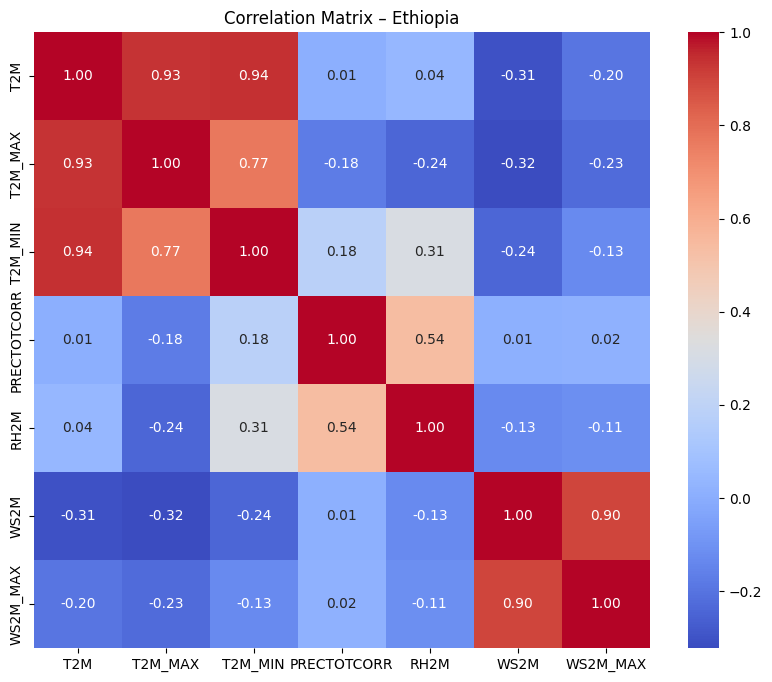

In [14]:
plt.figure(figsize=(10,8))
corr = df[cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Matrix – Ethiopia')
plt.show()

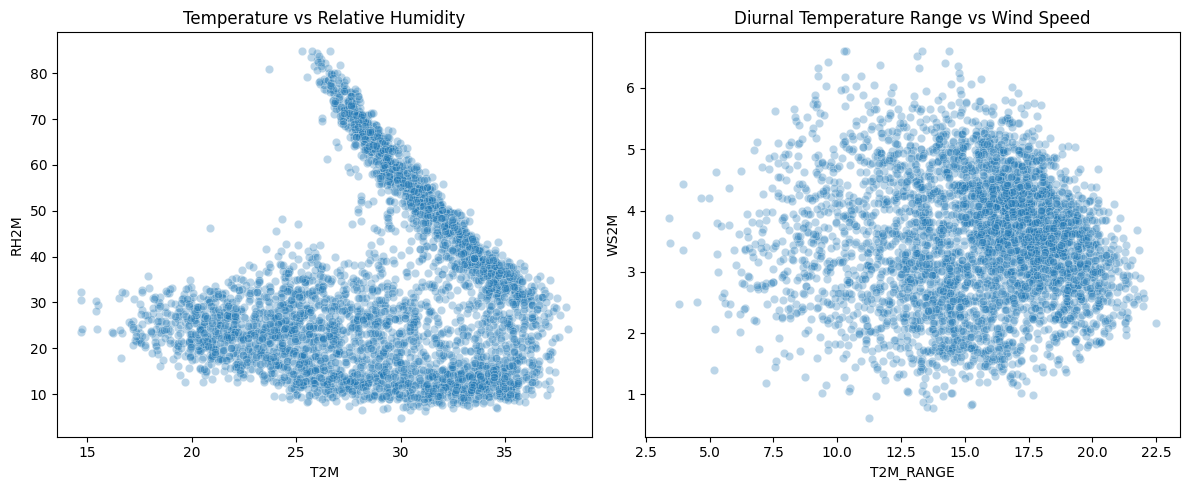

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.scatterplot(data=df, x='T2M', y='RH2M', alpha=0.3, ax=axes[0])
axes[0].set_title('Temperature vs Relative Humidity')
sns.scatterplot(data=df, x='T2M_RANGE', y='WS2M', alpha=0.3, ax=axes[1])
axes[1].set_title('Diurnal Temperature Range vs Wind Speed')
plt.tight_layout()
plt.show()

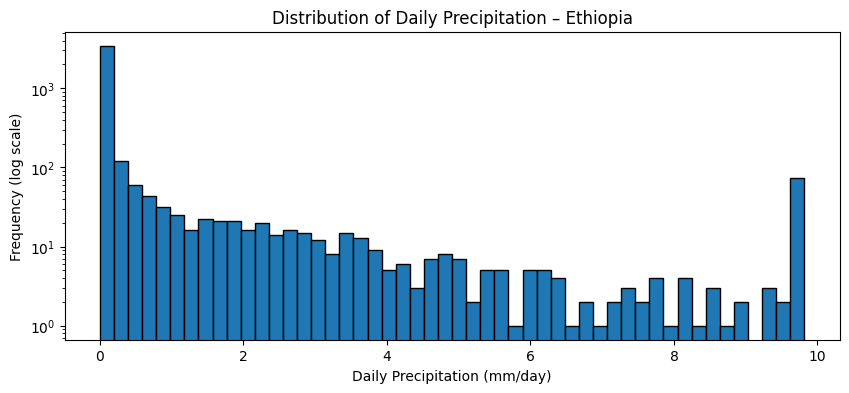

In [16]:
plt.figure(figsize=(10,4))
plt.hist(df['PRECTOTCORR'], bins=50, edgecolor='black')
plt.yscale('log')
plt.xlabel('Daily Precipitation (mm/day)')
plt.ylabel('Frequency (log scale)')
plt.title('Distribution of Daily Precipitation – Ethiopia')
plt.show()

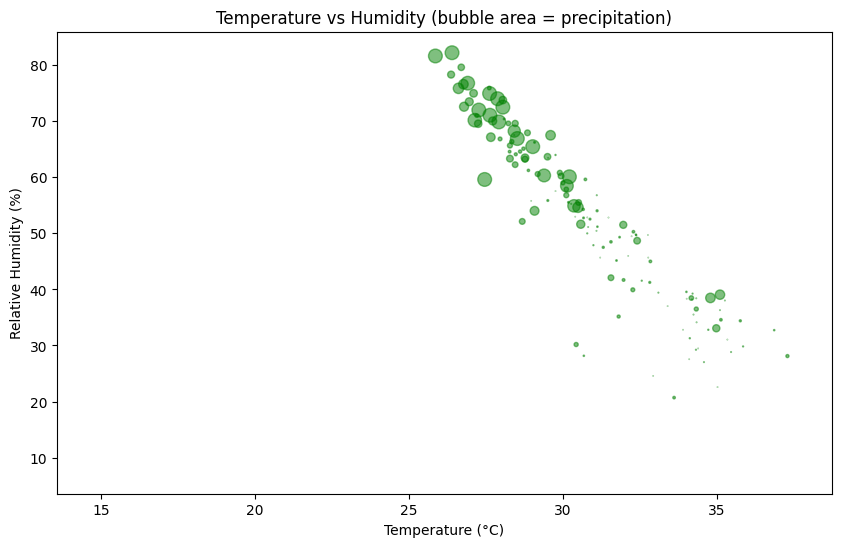

In [17]:
sample = df.sample(min(500, len(df)))  
plt.figure(figsize=(10,6))
plt.scatter(sample['T2M'], sample['RH2M'], s=sample['PRECTOTCORR']*10, alpha=0.5, c='green')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Temperature vs Humidity (bubble area = precipitation)')
plt.show()